# Inspired by the sklearn DataCamp unit

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, KFold

In [16]:
train_data = pd.read_csv("../data/processed/train_cleaned_temp.csv", index_col=0)
train_data.head()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Female,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly,Customer Status_inactive
0,160831,0.340426,0.813559,0.862069,0.0,0.566667,0.878011,1.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,354435,0.255319,0.593220,0.724138,0.0,0.500000,0.949300,1.000000,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,444576,0.106383,0.728814,0.448276,0.0,0.800000,0.637778,0.689655,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3,130847,0.127660,0.644068,0.689655,0.2,0.466667,0.750000,0.586207,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,108121,0.170213,0.813559,0.862069,0.1,0.166667,0.643833,0.241379,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [17]:
X = train_data.drop(["Churn", "Customer Status_inactive"], axis=1).values
y = train_data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=754, stratify=y)

In [18]:
# parameters = {"alpha":np.arange(0.00001, 10, 500)}

# kf=KFold(n_splits=10,shuffle=True, random_state=754)

# lasso = Lasso()

# cross_val = GridSearchCV(lasso, param_grid=parameters, cv=kf)
# cross_val.fit(X, y)
# print(f"Best alpha: {cross_val.best_params_}")

In [19]:
cols = train_data.drop(["Churn", "Customer Status_inactive"], axis=1).columns

find_features = Lasso(alpha=0.00001)
find_features.fit(X_train, y_train)

importance = np.abs(find_features.coef_)

/opt/miniconda3/envs/MAT311-Final-env/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.083e+02, tolerance: 5.092e+00
  model = cd_fast.enet_coordinate_descent(


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'CustomerID'),
  Text(1, 0, 'Age'),
  Text(2, 0, 'Tenure'),
  Text(3, 0, 'Usage Frequency'),
  Text(4, 0, 'Support Calls'),
  Text(5, 0, 'Payment Delay'),
  Text(6, 0, 'Total Spend'),
  Text(7, 0, 'Last Interaction'),
  Text(8, 0, 'Gender_Female'),
  Text(9, 0, 'Subscription Type_Basic'),
  Text(10, 0, 'Subscription Type_Premium'),
  Text(11, 0, 'Subscription Type_Standard'),
  Text(12, 0, 'Contract Length_Annual'),
  Text(13, 0, 'Contract Length_Monthly'),
  Text(14, 0, 'Contract Length_Quarterly')])

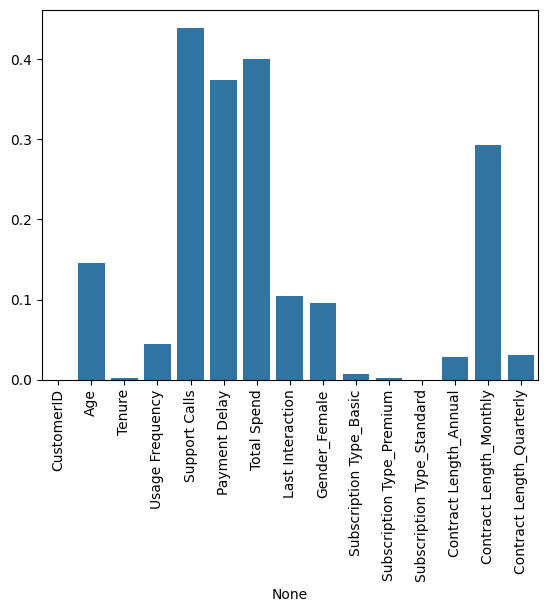

In [20]:
sns.barplot(x=cols, y=importance)
plt.xticks(rotation=90)

In [21]:
feature_subset=np.array(cols)[importance>0.1]
print("Selected Feature Columns: {}".format(feature_subset))

Selected Feature Columns: ['Age' 'Support Calls' 'Payment Delay' 'Total Spend' 'Last Interaction'
 'Contract Length_Monthly']
